# Systematics: what the ground-spill block looks like

The sampler's model is `d = w * (Us s + Uf f) + n`. `imgibbs.systematics` adds
an optional third component,

$$d = w\,(U_s s + U_f f + U_g g) + n$$

where $U_g$ is a **fixed, low-rank** basis of systematic templates and $g$ a
short vector of amplitudes sampled jointly with everything else.

This notebook shows the *structure* of that block — what the templates are, why
they were chosen, and what a foreground clean does to them. It does not run the
sampler. For that, see `scripts/groundspill_injection.py` and
`docs/STATUS.md`.

Everything here runs on data shipped with the repository; the MeerKLASS L2021
cubes are not needed.


In [1]:
# Run from the repo without installing: `pip install -e ..` makes this unnecessary.
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from imgibbs import (
    data_path, groundspill_basis, groundspill_cube, load, period_scan,
    ripple_wavenumber, scan_templates, spectral_templates,
    spillover_envelope, survey_grid,
)
import json

# The live grid. Everything follows CROP -- see imgibbs/grid.py.
CROP = (slice(33, 103), slice(14, 59), slice(0, 250))
SHAPE = (70, 45, 250)
N_MODES = 6          # foreground modes the sampler actually runs with
PERIOD = 17.5        # standing-wave period, MHz

grid = survey_grid(CROP, SHAPE)
FREQS = grid.freqs
BAND = FREQS[-1] - FREQS[0]
print(grid.summary())
print(f'\nband width   : {BAND:.2f} MHz')

shape         : (70, 45, 250)
channel width : 0.208984 MHz
channels      : 550 - 799  (250 kept)
frequency     : 970.94 - 1022.98 MHz
redshift      : 0.3885 - 0.4629  (mid 0.4257)
D_M(z_mid)    : 1640.0 Mpc
angular       : 21.0 x 13.5 deg
box_dims      : (601.1, 386.4, 254.4) Mpc
voxel         : 8.59 x 8.59 x 1.02 Mpc

band width   : 52.04 MHz


In [2]:
# Plot style: recessive chrome, categorical hues assigned in fixed order.
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'

plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 140,
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.linewidth': 0.8, 'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelcolor': INK2, 'ytick.labelcolor': INK2,
    'legend.frameon': False, 'font.size': 9, 'lines.linewidth': 1.8,
})

# Diverging: two poles + a NEUTRAL GRAY midpoint, for signed patterns.
DIVERGING = LinearSegmentedColormap.from_list(
    'gs_div', ['#0d366b', '#2a78d6', '#f0efec', '#e34948', '#8f2320'])


def bare(ax, right=True, top=True):
    """Drop the spines that carry no information."""
    for side in (['right'] if right else []) + (['top'] if top else []):
        ax.spines[side].set_visible(False)


def signed(ax, field, label=None, lim=None, transpose=True):
    """Show a signed map on the diverging scale, centred on zero.

    Pass ``lim`` to share one scale across panels. Without it each panel is
    normalised to its own maximum, which makes a CONSTANT pattern saturate and
    read as extreme when it is merely uniform.
    """
    lim = lim or (np.abs(field).max() or 1.0)
    im = ax.imshow(field.T if transpose else field, origin='lower',
                   cmap=DIVERGING, aspect='auto',
                   norm=TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if label:
        ax.set_title(label, fontsize=9, color=INK)
    return im

## 1. The spectrum: a smooth envelope and a ripple

Ground spill is far-sidelobe pickup of ~280 K ground emission. Two pieces, and
they behave completely differently in this sampler:

* a **smooth envelope** — the spillover fraction rises toward low frequency
  roughly as the beam solid angle, $(\nu/\nu_{\rm ref})^{-2}$;
* a **standing-wave ripple**, set by the round trip between dish and
  subreflector, modulating that envelope.

The ripple enters the basis as a **cosine/sine pair** rather than an amplitude
and a phase. Amplitude and phase are a nonlinear pair; the two quadratures are
linear parameters, which is the whole reason this block fits inside the
constrained realisation with no Metropolis step. The *period* is genuinely
nonlinear, and is fixed rather than sampled.

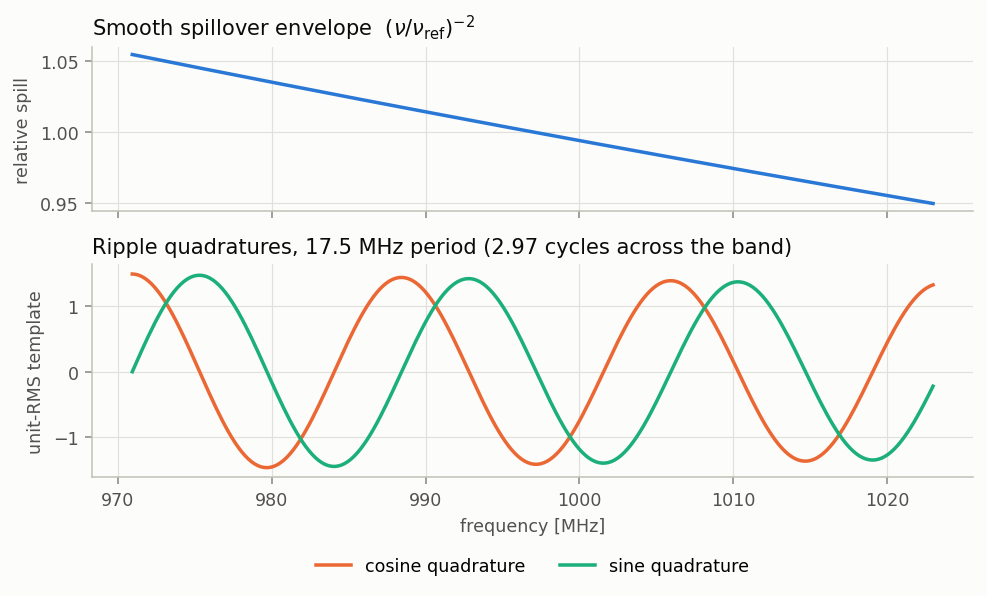

In [3]:
env = spillover_envelope(FREQS)
templates = spectral_templates(FREQS, period=PERIOD, n_harmonics=1)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1.3]})

ax0.plot(FREQS, env, color=BLUE)
ax0.set_ylabel('relative spill')
ax0.set_title('Smooth spillover envelope  $(\\nu/\\nu_{\\rm ref})^{-2}$',
              loc='left')
bare(ax0)

ax1.plot(FREQS, templates[0], color=ORANGE, label='cosine quadrature')
ax1.plot(FREQS, templates[1], color=AQUA, label='sine quadrature')
ax1.set_xlabel('frequency [MHz]')
ax1.set_ylabel('unit-RMS template')
ax1.set_title(f'Ripple quadratures, {PERIOD:g} MHz period '
              f'({BAND / PERIOD:.2f} cycles across the band)', loc='left')
ax1.legend(loc='upper center', ncols=2, bbox_to_anchor=(0.5, -0.3))
bare(ax1)

fig.tight_layout()

## 2. What the foreground block can already absorb

This is the measurement the whole design rests on.

The foreground block has **per-pixel free amplitudes** on `n_modes` smooth
frequency modes. So anything smooth in frequency lies inside its span *whatever
its spatial structure is* — there is no spatial pattern distinctive enough to
rescue it.

Two consequences:

* The **smooth envelope is absorbed to machine precision** at every `n_modes`.
  It is unidentifiable, and harmless for exactly the same reason. That is why
  `spectral_templates` leaves it out by default: putting it in $U_g$ would only
  add a direction the data cannot constrain.
* The **ripple survives**, and how much survives depends on the period *and*
  the bandwidth. Raising `n_modes` does absorb it — but `docs/STATUS.md`
  records that `n_modes = 20` removes the 21cm signal too ($T(k)$ 0.006–0.06)
  and pushes $\tau_{\rm int}$ to 54–105. That cure is worse than the disease.

The lower panel is why it matters: a ripple is a **single $k_\parallel$ mode**,
so it does not spread across bins — it dumps all of its power into one.

k-bins       : 0.0684, 0.1599, 0.3740, 0.8748, 2.0462
modes/bin    : [898, 12474, 106814, 209276, 454834]
17.5 MHz ripple -> k_par 0.0734 Mpc^-1, nearest bin 0
foreground absorbs n=6: 18.4%, n=10: 93.8%, n=20: 100.0%


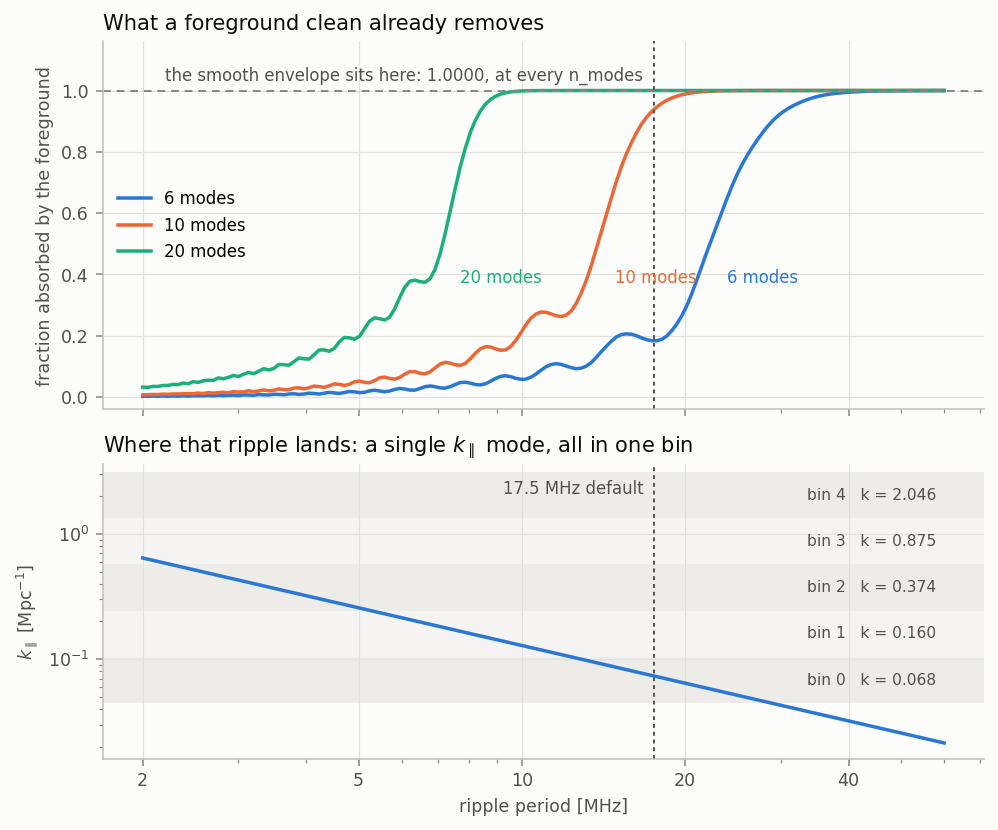

In [4]:
def legendre_basis(n_freq, n_modes):
    """The sampler's foreground basis: orthonormalised Legendre polynomials."""
    vander = np.polynomial.legendre.legvander(np.linspace(-1, 1, n_freq),
                                              n_modes - 1)
    return np.linalg.qr(vander)[0].T


periods = np.logspace(np.log10(2.0), np.log10(60.0), 160)
k_of_period = ripple_wavenumber(periods, BAND, grid.box_dims[2])

# The sampler's ACTUAL k-bins, recovered from the shipped S rather than
# re-derived. kbins_from_crop takes k_min from the observed footprint, so
# calling it on anything but the real mask silently gives different bins --
# which is the trap docs/STATUS.md describes at length. S is piecewise-constant
# over the bins, so its distinct values ARE the binning, and the counts check
# against the metadata the run recorded.
meta = json.loads(data_path('S_starting_point_cropped_meta.json').read_text())
sig_k = np.array(meta['kbin_sig_k'])
_S = load('S_starting_point_cropped.npy')
_vals, _counts = np.unique(_S, return_counts=True)

idxs = np.zeros(_S.size, dtype=int)
for i, n_modes_in_bin in enumerate(meta['kbin_modes_per_bin']):
    match = _vals[_counts == n_modes_in_bin]
    assert len(match) == 1, f'bin {i}: {len(match)} S values with {n_modes_in_bin} modes'
    idxs[_S == match[0]] = i + 1
assert (idxs > 0).sum() == sum(meta['kbin_modes_per_bin'])
kbin_meta = {'k_min': meta['kbin_k_min'], 'k_max': meta['kbin_k_max']}
print('k-bins       : ' + ', '.join(f'{k:.4f}' for k in sig_k))
print('modes/bin    : ' + str(meta['kbin_modes_per_bin']))

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.2, 6.0), sharex=True,
                               gridspec_kw={'height_ratios': [1.25, 1]})

for n_modes, colour in ((6, BLUE), (10, ORANGE), (20, AQUA)):
    absorbed = period_scan(FREQS, periods, legendre_basis(len(FREQS), n_modes))
    ax0.plot(periods, absorbed, color=colour, label=f'{n_modes} modes')
    # Label each curve where they are furthest apart -- their 50% crossings --
    # rather than at the right edge, where all three sit on top of each other.
    ax0.annotate(f'{n_modes} modes', xy=(np.interp(0.5, absorbed, periods), 0.5),
                 xytext=(9, -20), textcoords='offset points',
                 ha='left', fontsize=8.5, color=colour)

env_absorbed = float(np.sum((legendre_basis(len(FREQS), 6)
                             @ (env / np.linalg.norm(env))) ** 2))
ax0.axhline(env_absorbed, color=MUTED, lw=1.0, ls=(0, (4, 3)))
ax0.annotate(f'the smooth envelope sits here: {env_absorbed:.4f}, '
             f'at every n_modes', xy=(2.2, env_absorbed), xytext=(0, 5),
             textcoords='offset points', fontsize=8.5, color=INK2)

ax0.set_ylabel('fraction absorbed by the foreground')
ax0.set_ylim(-0.04, 1.16)
ax0.set_title('What a foreground clean already removes', loc='left')
ax0.legend(loc='center left', fontsize=8.5)
bare(ax0)

# Where the ripple lands in k, against the sampler's actual bins.
edges = np.concatenate([[kbin_meta['k_min']], np.sqrt(sig_k[1:] * sig_k[:-1]),
                        [kbin_meta['k_max']]])
for i, k in enumerate(sig_k):
    ax1.axhspan(edges[i], edges[i + 1], color=GRID,
                alpha=0.55 if i % 2 == 0 else 0.25, lw=0)
    # Right-aligned at the right edge: the curve falls left-to-right, so that
    # corner is the one part of the panel it never crosses.
    ax1.annotate(f'bin {i}   k = {k:.3f}', xy=(periods[-1], k), xytext=(-4, 0),
                 textcoords='offset points', fontsize=8, color=INK2,
                 ha='right', va='center')

ax1.plot(periods, k_of_period, color=BLUE)
ax1.set_yscale('log')
ax1.set_ylim(k_of_period.min() * 0.75, float(kbin_meta['k_max']) * 1.15)
ax1.set_xscale('log')
ax1.set_xlabel('ripple period [MHz]')
ax1.set_ylabel(r'$k_\parallel$ [Mpc$^{-1}$]')
ax1.set_title(r'Where that ripple lands: a single $k_\parallel$ mode,'
              ' all in one bin', loc='left')
bare(ax1)

for ax in (ax0, ax1):
    ax.axvline(PERIOD, color=INK2, lw=1.0, ls=(0, (2, 2)))
ax1.annotate(f'{PERIOD:g} MHz default', xy=(PERIOD, kbin_meta['k_max']),
             xytext=(-5, -4), textcoords='offset points', fontsize=8.5,
             color=INK2, ha='right', va='top')
ax1.set_xticks([2, 5, 10, 20, 40])
ax1.set_xticklabels(['2', '5', '10', '20', '40'])

fig.tight_layout()

k_hit = ripple_wavenumber(PERIOD, BAND, grid.box_dims[2])
print(f'{PERIOD:g} MHz ripple -> k_par {k_hit:.4f} Mpc^-1, '
      f'nearest bin {int(np.argmin(np.abs(sig_k - k_hit)))}')
print('foreground absorbs',
      ', '.join(f'n={n}: {period_scan(FREQS, [PERIOD], legendre_basis(len(FREQS), n))[0]:.1%}'
                for n in (6, 10, 20)))

## 3. The spatial side: low order, not per-pixel

A drift scan at fixed elevation sees a ground pattern that is **constant in the
telescope frame**, so to lowest order it contributes the same in every map
pixel. What breaks that degeneracy is the azimuth covered within a scan, which
maps onto the scan direction of the map.

So the spatial model is a low-order polynomial along the scan axis — constant
plus gradient by default. Deliberately **not** per-pixel: per-pixel amplitudes
on a frequency template is exactly what $U_f$ already is, so a systematic with
that much spatial freedom would be unidentifiable no matter how distinctive its
spectrum.

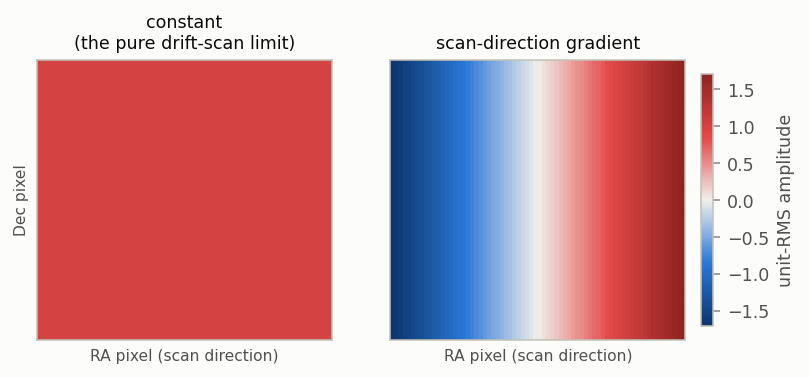

In [5]:
spatial = scan_templates(SHAPE, order=1, scan_axis=0)
names = ['constant\n(the pure drift-scan limit)', 'scan-direction gradient']

LIM = np.abs(spatial).max()      # one scale for both panels

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6))
for ax, row, name in zip(axes, spatial, names):
    im = signed(ax, row.reshape(SHAPE[0], SHAPE[1]), name, lim=LIM)
    ax.set_xlabel('RA pixel (scan direction)', fontsize=8)
axes[0].set_ylabel('Dec pixel', fontsize=8)
fig.colorbar(im, ax=axes, label='unit-RMS amplitude', pad=0.02, shrink=0.9)

## 4. The basis is separable, and that is what makes it cheap

Each template is an outer product, `spatial[s] x spectral[t]`, so the amplitude
array `g` has shape `(n_s, n_t)` — **four numbers by default**.

Separability is not a cosmetic choice. It means:

* applying $U_g$ is two small matrix multiplies rather than a pass over
  ~800,000 voxels;
* the Gram matrix the preconditioner needs **factorises exactly**,
  $U_g^{\mathsf T}U_g = \mathrm{kron}(G_{\rm spatial}, G_{\rm spectral})$ — an
  identity, not an approximation.

The grid below is literally that outer product: rows are spatial patterns,
columns are spectral quadratures, and each panel is one basis element shown at
a single frequency channel.

2 spatial x 2 spectral = 4 parameters, g has shape (2, 2)


Text(0.02, 0.98, 'The four basis elements: spatial pattern x spectral template')

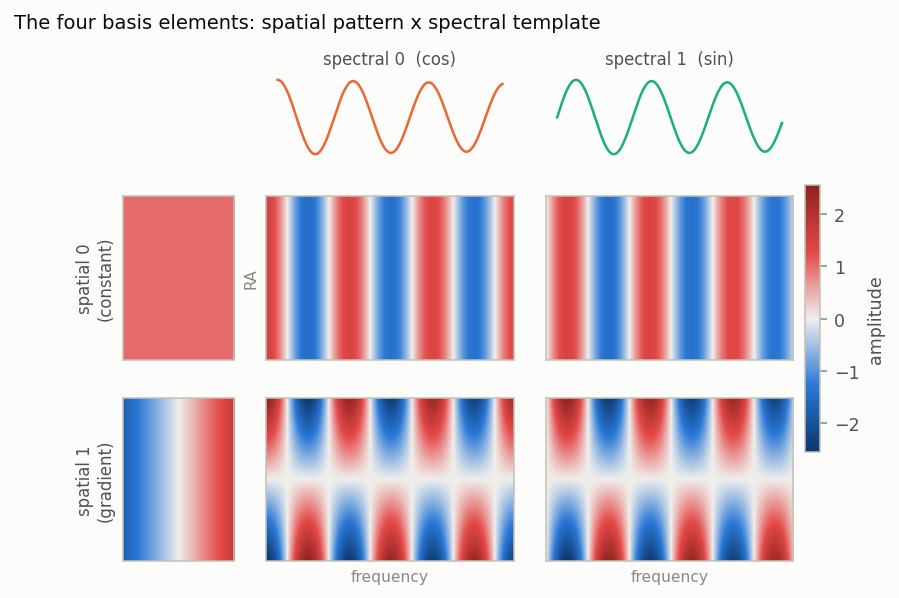

In [6]:
basis = groundspill_basis(FREQS, SHAPE, period=PERIOD, order=1)
print(f'{basis.n_s} spatial x {basis.n_t} spectral = {basis.n_params} '
      f'parameters, g has shape {basis.g_shape}')

# Each product is shown as an RA-frequency slice at mid-Dec, NOT a sky map at
# one channel: a single channel cannot show the difference between the two
# quadratures, because they differ in phase ALONG frequency. In this view the
# phase shift between the columns is the visible thing.
dec = SHAPE[1] // 2

fig = plt.figure(figsize=(7.4, 4.5))
gs = fig.add_gridspec(3, 3, height_ratios=[0.5, 1, 1],
                      width_ratios=[0.45, 1, 1], hspace=0.28, wspace=0.16)

# Top row: the two spectral templates.
for t in range(basis.n_t):
    ax = fig.add_subplot(gs[0, t + 1])
    ax.plot(FREQS, basis.spectral[t], color=ORANGE if t == 0 else AQUA, lw=1.3)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'spectral {t}  ({"cos" if t == 0 else "sin"})', fontsize=8.5,
                 color=INK2)

# One scale across every map below, so a uniform pattern does not saturate.
LIM = max(np.abs(basis.spatial).max(),
          max(np.abs(basis.cube(np.eye(basis.n_params)[i])[:, dec, :]).max()
              for i in range(basis.n_params)))

# Left column: the two spatial patterns, as sky maps.
for sp in range(basis.n_s):
    ax = fig.add_subplot(gs[sp + 1, 0])
    signed(ax, basis.spatial[sp].reshape(SHAPE[0], SHAPE[1]), lim=LIM)
    ax.set_ylabel(f'spatial {sp}\n({"constant" if sp == 0 else "gradient"})',
                  fontsize=8.5, color=INK2)

# The products, as RA x frequency.
for sp in range(basis.n_s):
    for t in range(basis.n_t):
        ax = fig.add_subplot(gs[sp + 1, t + 1])
        g = np.zeros(basis.g_shape)
        g[sp, t] = 1.0
        im = signed(ax, basis.cube(g)[:, dec, :], lim=LIM, transpose=False)
        if sp == basis.n_s - 1:
            ax.set_xlabel('frequency', fontsize=8, color=MUTED)
        if t == 0 and sp == 0:
            ax.set_ylabel('RA', fontsize=8, color=MUTED)
fig.colorbar(im, ax=fig.axes, label='amplitude', pad=0.015, shrink=0.55,
             aspect=18)

fig.suptitle(f'The four basis elements: spatial pattern x spectral template',
             x=0.02, ha='left', fontsize=10, color=INK)

## 5. What a foreground clean leaves behind

Inject ground spill with a large smooth part and a small ripple, then fit and
subtract the same 6-mode Legendre basis the sampler uses.

The smooth part is 500x the ripple on the way in, and **gone** on the way out.
The ripple is what remains — which is the entire argument for modelling it
separately rather than buying the foreground more polynomials.

injected  : smooth 0.5 K, ripple 0.001 K
residual  : 9.037e-04 K after the clean
            = 90.4% of the injected ripple, and 1.81e-03 of the smooth part


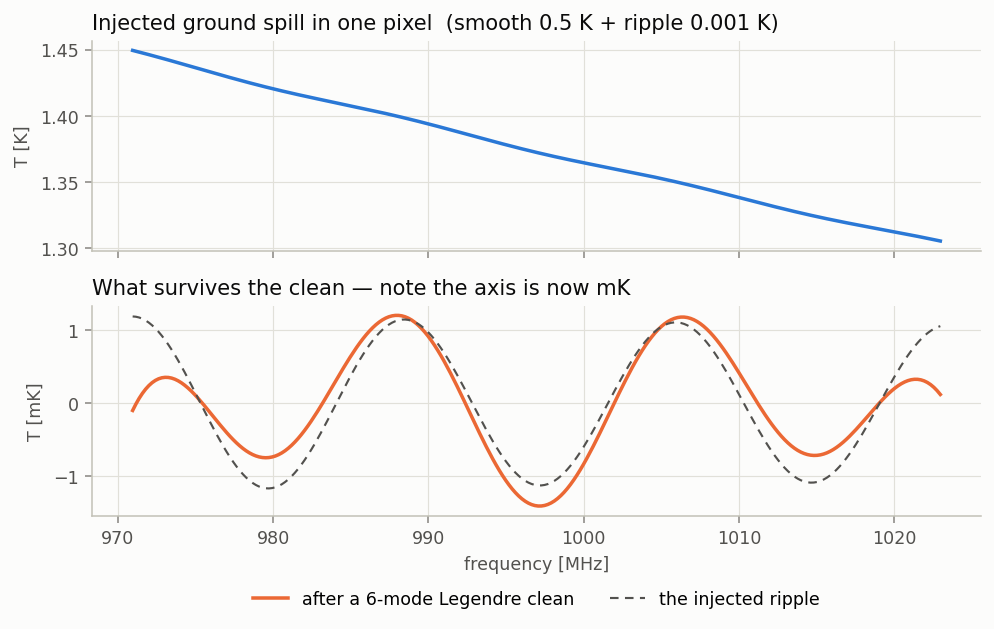

In [7]:
RIPPLE_RMS, SPILL_LEVEL = 1e-3, 0.5
spill, truth = groundspill_cube(FREQS, SHAPE, ripple_rms=RIPPLE_RMS,
                                spill_level=SPILL_LEVEL, period=PERIOD,
                                rng=np.random.default_rng(0))
ripple_only = truth['basis'].cube(truth['g_true'])

fg = legendre_basis(len(FREQS), N_MODES)
residual = spill.reshape(-1, len(FREQS))
residual = (residual - (residual @ fg.T) @ fg).reshape(SHAPE)

px = (SHAPE[0] // 3, SHAPE[1] // 2)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.2, 4.6), sharex=True)

ax0.plot(FREQS, spill[px], color=BLUE)
ax0.set_ylabel('T [K]')
ax0.set_title(f'Injected ground spill in one pixel  '
              f'(smooth {SPILL_LEVEL:g} K + ripple {RIPPLE_RMS:g} K)',
              loc='left')
bare(ax0)

ax1.plot(FREQS, residual[px] * 1e3, color=ORANGE,
         label=f'after a {N_MODES}-mode Legendre clean')
ax1.plot(FREQS, ripple_only[px] * 1e3, color=INK2, lw=1.1, ls=(0, (4, 3)),
         label='the injected ripple')
ax1.set_xlabel('frequency [MHz]')
ax1.set_ylabel('T [mK]')
ax1.set_title('What survives the clean — note the axis is now mK', loc='left')
ax1.legend(loc='upper center', ncols=2, bbox_to_anchor=(0.5, -0.28))
bare(ax1)

fig.tight_layout()

print(f'injected  : smooth {SPILL_LEVEL:.3g} K, ripple {RIPPLE_RMS:.3g} K')
print(f'residual  : {residual.std():.3e} K after the clean')
print(f'            = {residual.std() / RIPPLE_RMS:.1%} of the injected ripple,'
      f' and {residual.std() / SPILL_LEVEL:.2e} of the smooth part')

## 6. Why it matters: the residual sits on the signal bins

The simulated H I cube is the truth curve the sampler is judged against. The
ripple residual lands on top of it, in one bin.

The contamination is **not broadband** — it is a spike. That is what makes it
both dangerous (it is exactly the shape of a detection) and tractable (four
parameters describe it).

bin 0  k =  0.0684   residual / H I =    96.19
bin 1  k =  0.1599   residual / H I =     0.17
bin 2  k =  0.3740   residual / H I =     0.01
bin 3  k =  0.8748   residual / H I =     0.00
bin 4  k =  2.0462   residual / H I =     0.00


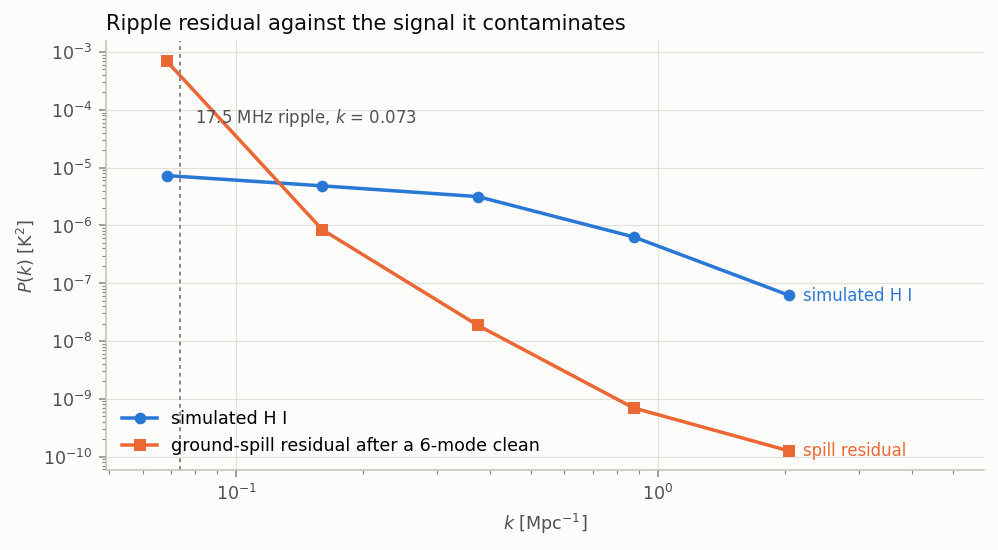

In [8]:
hi = load('Fastbox_cube_cropped.npy')
occupied = np.unique(idxs)
occupied = occupied[occupied > 0]


def pk(cube):
    """Binned P(k), same convention and binning as the sampler's SCS step."""
    A = np.fft.fftn(cube - cube.mean(), norm='ortho').flatten()
    p = (A * np.conj(A)).real
    return np.array([p[idxs == b].mean() for b in occupied])


fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(sig_k, pk(hi), color=BLUE, marker='o', ms=5, label='simulated H I')
ax.plot(sig_k, pk(residual), color=ORANGE, marker='s', ms=5,
        label=f'ground-spill residual after a {N_MODES}-mode clean')
ax.axvline(k_hit, color=MUTED, lw=1.0, ls=(0, (2, 2)))
ax.annotate(f'{PERIOD:g} MHz ripple, $k$ = {k_hit:.3f}',
            xy=(k_hit, np.sqrt(pk(hi)[0] * pk(residual)[0])), xytext=(8, 0),
            textcoords='offset points', fontsize=8.5, color=INK2, va='center')
# Direct labels at the right ends, where the two curves are well separated.
for series, colour, name in ((pk(hi), BLUE, 'simulated H I'),
                             (pk(residual), ORANGE, 'spill residual')):
    ax.annotate(name, xy=(sig_k[-1], series[-1]), xytext=(7, 0),
                textcoords='offset points', fontsize=8.5, color=colour,
                va='center')
ax.set_xlim(sig_k[0] * 0.72, sig_k[-1] * 2.9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_ylabel(r'$P(k)$ [K$^2$]')
ax.set_title('Ripple residual against the signal it contaminates', loc='left')
ax.legend(loc='lower left')
bare(ax)
fig.tight_layout()

ratio = pk(residual) / pk(hi)
for i, (k, r) in enumerate(zip(sig_k, ratio)):
    print(f'bin {i}  k = {k:7.4f}   residual / H I = {r:8.2f}')

## Where to go from here

The block is off by default everywhere — `sys_basis=None` leaves the published
three-block sampler numerically identical. To turn it on:

```bash
python scripts/run_gibbs.py 6 --groundspill --gs-period 17.5
```

On real data you cannot distinguish a systematic that was *removed* from one
that was never *there* — the same structural limitation `docs/STATUS.md`
records for the Gibbs-vs-PCA comparison. So the thing to run first is the
injection test, which builds a synthetic cube with a known answer and samples
it twice, differing only in whether the block is on:

```bash
python scripts/groundspill_injection.py --arm off --n-samples 120
python scripts/groundspill_injection.py --arm on  --n-samples 120
python scripts/groundspill_injection.py --summarise
```

**The block can only ever recover the part of the ripple the foreground does
not already take** — the upper panel of §2 is the ceiling on what any run can
demonstrate. Both scripts print it before they start.

Open, and worth knowing before you trust a result:

* the **period is fixed, not sampled**. Getting it wrong is the interesting
  failure mode and is untested; a search over it needs a nonlinear step.
* **`G` is a prior, not a sampled covariance.** `F` can be drawn from an
  inverse-Wishart because `Npix` amplitude vectors stand behind it; `g` is four
  numbers, and four numbers do not identify their own covariance.
* **only ground spill so far.** A multiplicative systematic — a gain error —
  does not fit this block at all, and would need linearisation or a separate
  Metropolis step.